# EDA: `order_payments`

Разведочный анализ таблицы `order_payments` из базы данных Olist.


### Импорты

In [1]:
import pandas as pd

import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from sqlalchemy.engine import URL

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

True

### Конфигурация

In [3]:
USERNAME = os.getenv("DB_USERNAME")
PASSWORD = os.getenv("DB_PASSWORD")
HOST = os.getenv("DB_HOST")
PORT = os.getenv("DB_PORT")
DATABASE = os.getenv("DB_NAME")

url = URL.create(
    drivername="postgresql+psycopg2",
    username=USERNAME,
    password=PASSWORD,
    host=HOST,
    port=PORT,
    database=DATABASE,
)

In [4]:
connection = create_engine(url=url)

## Анализ данных


In [5]:
read_sql_query = "SELECT * FROM order_payments"
df = pd.read_sql(sql=read_sql_query, con=connection)

In [6]:
df.head()

,payment_sequential,payment_type,payment_installments,payment_value,order_id
0,1,credit_card,8,99.33,b81ef226f3fe1789b1e8b2acac839d17
1,1,credit_card,1,24.39,a9810da82917af2d9aefd1278f1dcfa0
2,1,credit_card,1,65.71,25e8ea4e93396b6fa0d3dd708e76c1bd
3,1,credit_card,8,107.78,ba78997921bbcdc1373bb41e913ab953
4,1,credit_card,2,128.45,42fdf880ba16b47b59251dd489d4441a


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   payment_sequential    103886 non-null  int64  
 1   payment_type          103886 non-null  str    
 2   payment_installments  103886 non-null  int64  
 3   payment_value         103886 non-null  float64
 4   order_id              103886 non-null  str    
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


In [8]:
df.describe(include='all')

,payment_sequential,payment_type,payment_installments,payment_value,order_id
count,103886.000000,103886,103886.000000,103886.000000,103886
unique,NaN,5,NaN,NaN,99440
top,NaN,credit_card,NaN,NaN,fa65dad1b0e818e3ccc5cb0e39231352
freq,NaN,76795,NaN,NaN,29
mean,1.092679,NaN,2.853349,154.100380,NaN
std,0.706584,NaN,2.687051,217.494064,NaN
min,1.000000,NaN,0.000000,0.000000,NaN
25%,1.000000,NaN,1.000000,56.790000,NaN
50%,1.000000,NaN,1.000000,100.000000,NaN
75%,1.000000,NaN,4.000000,171.837500,NaN


In [9]:
df.memory_usage(deep=True)

Index                       132
payment_sequential       831088
payment_type            6109611
payment_installments     831088
payment_value            831088
order_id                8414766
dtype: int64

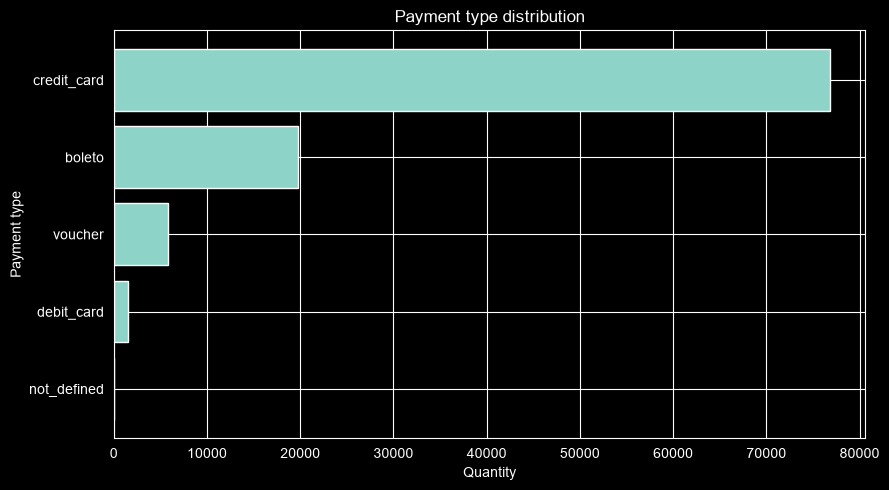

In [10]:
payment_counts = df["payment_type"].value_counts()

plt.figure(figsize=(9, 5))

bars = plt.barh(
    payment_counts.index,
    payment_counts.values
)

plt.xlabel("Quantity")
plt.ylabel("Payment type")
plt.title("Payment type distribution")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

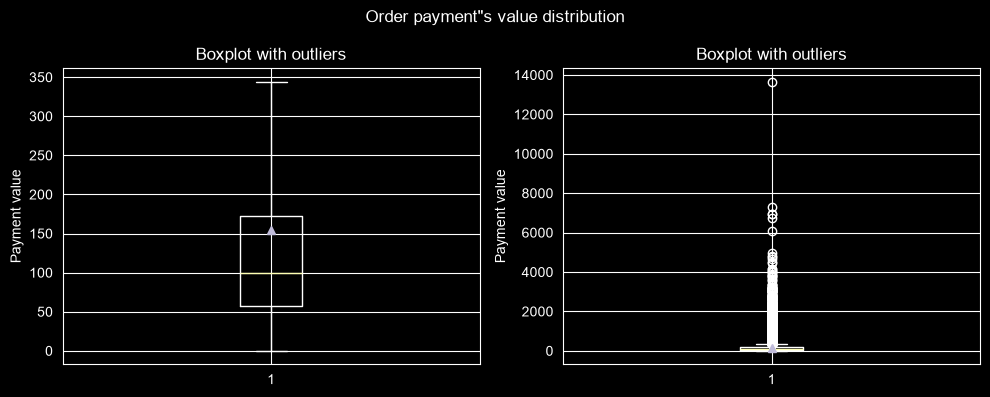

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Order payment"s value distribution')

ax[0].boxplot(
    df["payment_value"].dropna(),
    showmeans=True,
    showfliers=False,
)
ax[0].set_title("Boxplot with outliers")
ax[0].set_ylabel("Payment value")

ax[1].boxplot(
    df["payment_value"].dropna(),
    showmeans=True,
    showfliers=True,
)
ax[1].set_title("Boxplot with outliers")
ax[1].set_ylabel("Payment value")

plt.tight_layout()
plt.show()

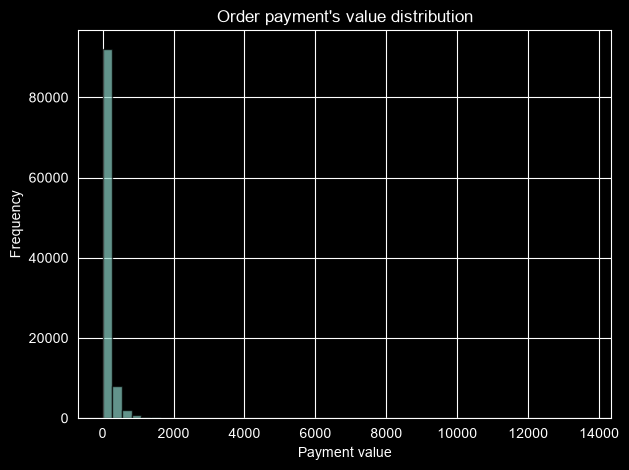

In [12]:
plt.hist(
    df["payment_value"].dropna(),
    bins=50,
    edgecolor="black",
    alpha=0.7
)
plt.title("Order payment's value distribution")
plt.xlabel("Payment value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()